In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/000/940/original/netflix.csv')

In [3]:
print("First 5 rows of the dataset:")
print(df.head())

First 5 rows of the dataset:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   


In [4]:
print("\nDataset Info:")
print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None


In [5]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       release_year
count   8807.000000
mean    2014.180198
std        8.819312
min     1925.000000
25%     2013.000000
50%     2017.000000
75%     2019.000000
max     2021.000000


In [6]:
content_counts = df['type'].value_counts()
print("\nContent Type Distribution:")
print(content_counts)



Content Type Distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


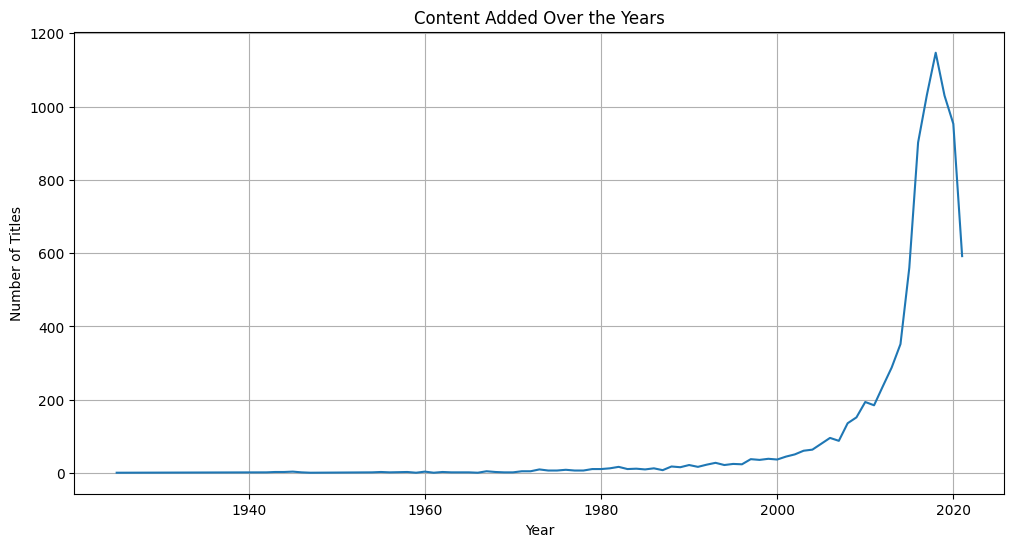

In [7]:
year_counts = df['release_year'].value_counts().sort_index()
plt.figure(figsize=(12, 6))
sns.lineplot(x=year_counts.index, y=year_counts.values)
plt.title('Content Added Over the Years')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.grid()
plt.show()


In [8]:
top_genres = df['listed_in'].value_counts().head(10)
print("\nTop 10 Genres:")
print(top_genres)


Top 10 Genres:
listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
Kids' TV                                            220
Children & Family Movies                            215
Children & Family Movies, Comedies                  201
Documentaries, International Movies                 186
Dramas, International Movies, Romantic Movies       180
Name: count, dtype: int64


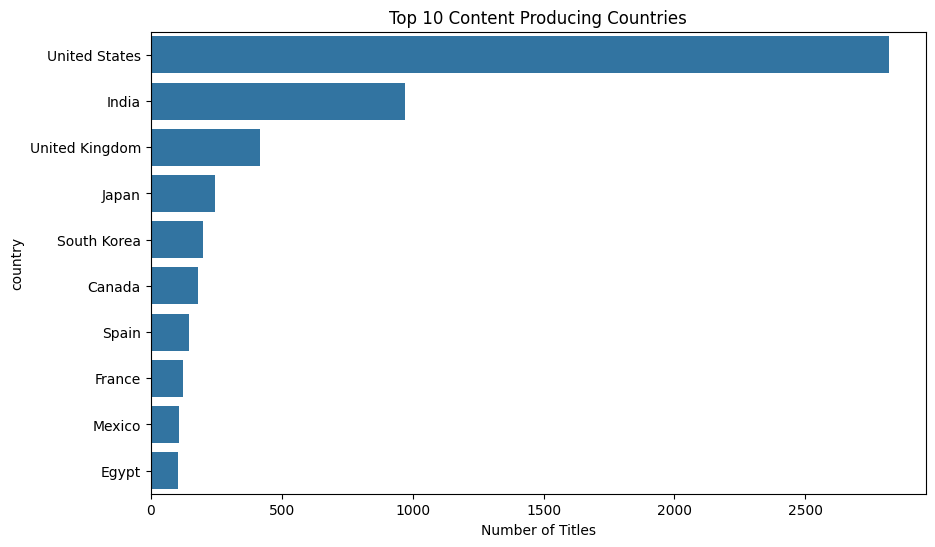

In [9]:
country_counts = df['country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=country_counts.values, y=country_counts.index)
plt.title('Top 10 Content Producing Countries')
plt.xlabel('Number of Titles')
plt.show()

In [10]:
rating_counts = df['rating'].value_counts()
print("\nContent Rating Distribution:")
print(rating_counts)


Content Rating Distribution:
rating
TV-MA       3207
TV-14       2160
TV-PG        863
R            799
PG-13        490
TV-Y7        334
TV-Y         307
PG           287
TV-G         220
NR            80
G             41
TV-Y7-FV       6
NC-17          3
UR             3
74 min         1
84 min         1
66 min         1
Name: count, dtype: int64


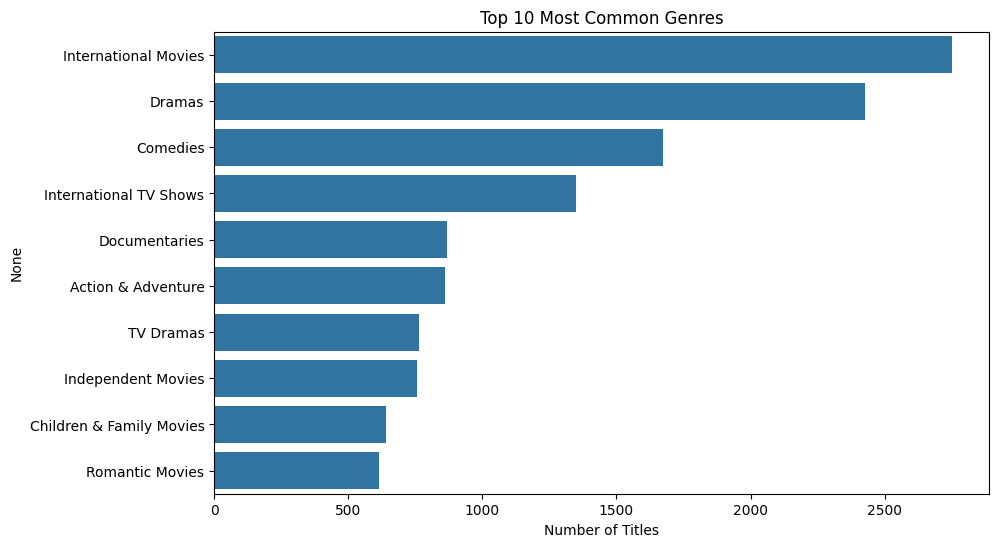

In [11]:
genre_split = df['listed_in'].dropna().str.split(', ')
all_genres = pd.Series([genre for sublist in genre_split for genre in sublist])

genre_counts = all_genres.value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index)
plt.title('Top 10 Most Common Genres')
plt.xlabel('Number of Titles')
plt.show()

In [12]:
director_counts = df['director'].dropna().value_counts().head(10)
print("\nTop 10 Directors:")
print(director_counts)



Top 10 Directors:
director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Marcus Raboy              16
Suhas Kadav               16
Jay Karas                 14
Cathy Garcia-Molina       13
Martin Scorsese           12
Youssef Chahine           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64


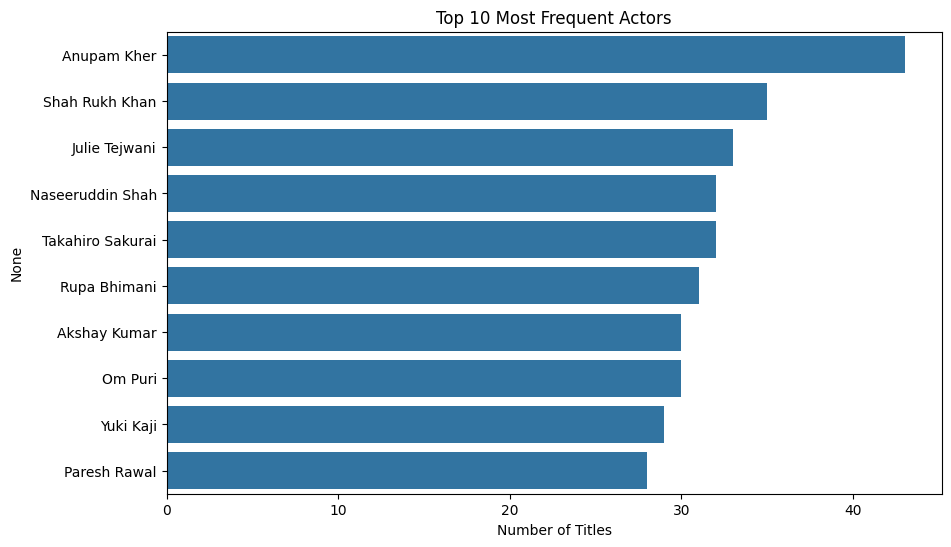

In [13]:
actor_split = df['cast'].dropna().str.split(', ')
all_actors = pd.Series([actor for sublist in actor_split for actor in sublist])

actor_counts = all_actors.value_counts().head(10)
plt.figure(figsize=(10, 6))
sns.barplot(x=actor_counts.values, y=actor_counts.index)
plt.title('Top 10 Most Frequent Actors')
plt.xlabel('Number of Titles')
plt.show()

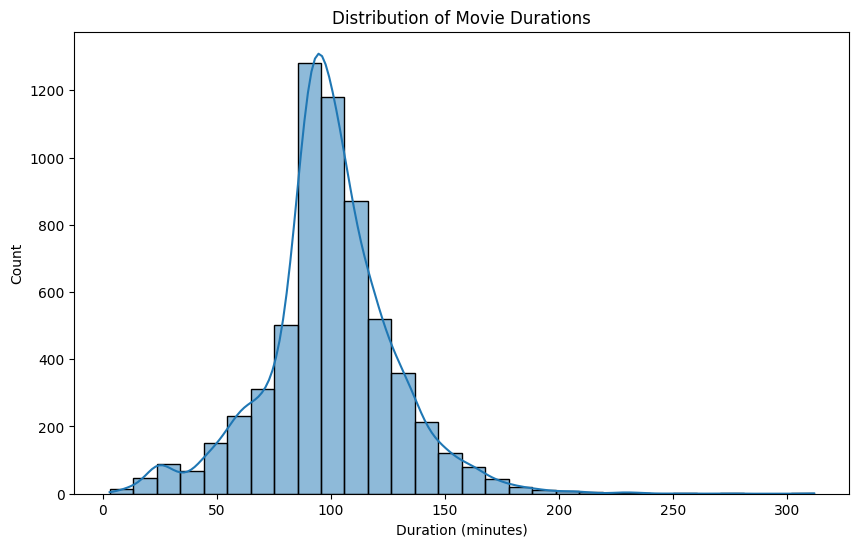

In [14]:
movie_durations = df[df['type'] == 'Movie']['duration'].str.replace(' min', '').dropna().astype(int)

plt.figure(figsize=(10, 6))
sns.histplot(movie_durations, bins=30, kde=True)
plt.title('Distribution of Movie Durations')
plt.xlabel('Duration (minutes)')
plt.show()


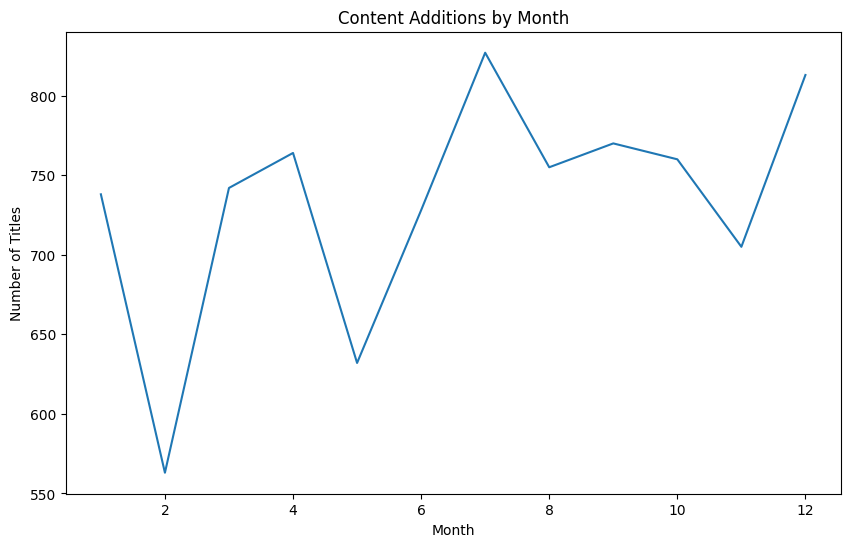

In [17]:
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(), errors='coerce')
df['month_added'] = df['date_added'].dt.month

monthly_counts = df['month_added'].value_counts().sort_index()
plt.figure(figsize=(10, 6))
sns.lineplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title('Content Additions by Month')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.show()